# Day 1 / 7 — Data, Windowing & Feature Engineering
### Regime-Aware PPO Portfolio Manager — CSE Banking Sector

**7-Day tuning plan (for reference):**

| Day | Focus |
|---|---|
| **1 (today)** | Data & windowing — window size, feature set, normalization, n_assets |
| 2 | Regime Encoder — VSN + LSTM (hidden size, layers, dropout) |
| 3 | Temporal Attention (MHA) — heads, attention dim |
| 4 | Macro Graph Prior (GNN/GAT) — layers, heads, edges |
| 5 | Actor Network — depth, width, learning rate, activations |
| 6 | Critic + Reward shaping — Sharpe window, EVaR penalty, transaction cost |
| 7 | PPO training loop — clip, epochs, batch size, gamma, GAE lambda — full ablation |

**Today's goal:** understand exactly what `x_t` (the temporal context fed into the Regime Encoder) looks like, and see how it changes when you tune:
1. `window_size`
2. which feature groups are engineered (`use_returns`, `use_volatility`, `use_momentum`, `use_volume_features`)
3. `normalize_method` (`zscore` / `minmax` / `robust`)
4. `n_assets`

You will not touch model code today at all — this is purely about the **Preprocessing Module** block in your diagram, i.e. `src/data/data_loader.py` and `src/data/preprocessor.py`, unmodified, called with different arguments.


## Step 0 — Setup

1. Upload your project zip (`Regime detection portfolio.zip`) using the file browser on the left, or run the upload cell below.
2. This notebook installs only what Day 1 needs (no `torch-geometric` yet — that's Day 4).


In [ ]:
# Upload the project zip (skip this cell if you already placed it in /content)
from google.colab import files
import os

if not os.path.exists('/content/Regime detection portfolio.zip') and not os.path.exists('/content/project'):
    uploaded = files.upload()  # choose your zip file


In [1]:
import os, zipfile, glob

ZIP_CANDIDATES = glob.glob('/content/*.zip')
PROJECT_DIR = '/content/project'

if not os.path.exists(PROJECT_DIR):
    assert ZIP_CANDIDATES, "No zip found in /content — upload it first."
    zip_path = ZIP_CANDIDATES[0]
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(PROJECT_DIR)
    print("Extracted:", zip_path)

# Find the actual project root (folder containing main.py)
ROOT = None
for dirpath, _, filenames in os.walk(PROJECT_DIR):
    if 'main.py' in filenames:
        ROOT = dirpath
        break
assert ROOT is not None, "Could not locate main.py inside the extracted zip."
print("Project root:", ROOT)


Extracted: /content/Regime detection portfolio.zip
Project root: /content/project/Regime detection portfolio


In [2]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn

In [3]:
import sys
sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config.config import get_config, DATA_RAW_DIR
from src.data.data_loader import CSEDataLoader
from src.data.preprocessor import Preprocessor

print("DATA_RAW_DIR:", DATA_RAW_DIR)
print(os.listdir(DATA_RAW_DIR))


DATA_RAW_DIR: /content/project/Regime detection portfolio/data/raw
['2021_banking_sector.csv', '2023_banking_sector.csv', '2022_banking_sector.csv', '2025_banking_sector.csv', '2024_banking_sector.csv']


## Step 1 — Baseline run (your current defaults)

This mirrors exactly what `main.py` does before training starts: load prices/volumes → engineer features → normalize → window.


In [4]:
config = get_config()
print("Baseline DataConfig:")
for k, v in vars(config.data).items():
    print(f"  {k}: {v}")


Baseline DataConfig:
  window_size: 30
  train_ratio: 0.7
  val_ratio: 0.15
  test_ratio: 0.15
  use_returns: True
  use_volatility: True
  use_momentum: True
  use_volume_features: True
  normalize_method: zscore
  asset_names: []
  n_assets: 0
  n_macro_variables: 0


In [5]:
loader = CSEDataLoader(raw_data_dir=DATA_RAW_DIR)
prices, volumes = loader.load_prices_and_volumes(n_assets=config.data.n_assets if config.data.n_assets > 0 else 47)
print("Prices shape (dates x assets):", prices.shape)
print("Date range:", prices.index.min(), "to", prices.index.max())
prices.head()


Prices shape (dates x assets): (836, 10)
Date range: 2021-01-04 00:00:00 to 2025-12-31 00:00:00


COMPANY ID,COMB,DFCC,HNB,NDB,PABC,SEYB,UBC,NTB,SAMP,ABL
TRADING DATE,,,,,,,,,,
2021-01-04,72.6,65.1,103.70,78.8,13.4,34.0,12.0,60.0,140.8,3.4
2021-01-05,72.7,66.0,104.40,79.3,13.6,34.9,13.4,60.4,142.5,3.4
2021-01-06,73.0,65.1,104.60,79.1,13.7,34.5,13.4,60.0,141.7,3.5
2021-01-07,73.1,65.0,104.10,78.3,13.9,35.0,13.5,60.1,141.3,3.4
2021-01-08,73.3,64.8,105.25,78.3,14.6,34.0,15.7,60.4,142.0,3.6


In [6]:
preprocessor = Preprocessor(window_size=config.data.window_size, normalize_method=config.data.normalize_method)
features = preprocessor.engineer_features(prices, volumes)
print("Engineered feature matrix shape:", features.shape)
print(f"-> {features.shape[1]} features per timestep, {features.shape[0]} timesteps after dropping NaNs from rolling windows")
features.iloc[:3, :8]


Engineered feature matrix shape: (816, 150)
-> 150 features per timestep, 816 timesteps after dropping NaNs from rolling windows


,COMB,DFCC,HNB,NDB,PABC,SEYB,UBC,NTB
TRADING DATE,,,,,,,,
2021-02-03,0.034829,0.043001,0.034938,0.027369,0.037338,0.073331,-0.007435,0.024531
2021-02-05,-0.001223,-0.014620,0.000000,-0.028479,-0.010526,0.010050,-0.015038,-0.008110
2021-02-08,-0.002451,-0.040577,-0.030503,-0.004454,-0.065597,-0.040822,-0.030772,-0.006536


In [7]:
normalized = preprocessor.fit_normalize(features)
windows = preprocessor.create_windows(normalized.values)
print("Windows shape (N, window_size, F):", windows.shape)
print(f"-> This is the x_t tensor shape that feeds the Regime Encoder. n_features = window_size * n_assets * ~7 feature types (roughly).")


Windows shape (N, window_size, F): (787, 30, 150)
-> This is the x_t tensor shape that feeds the Regime Encoder. n_features = window_size * n_assets * ~7 feature types (roughly).


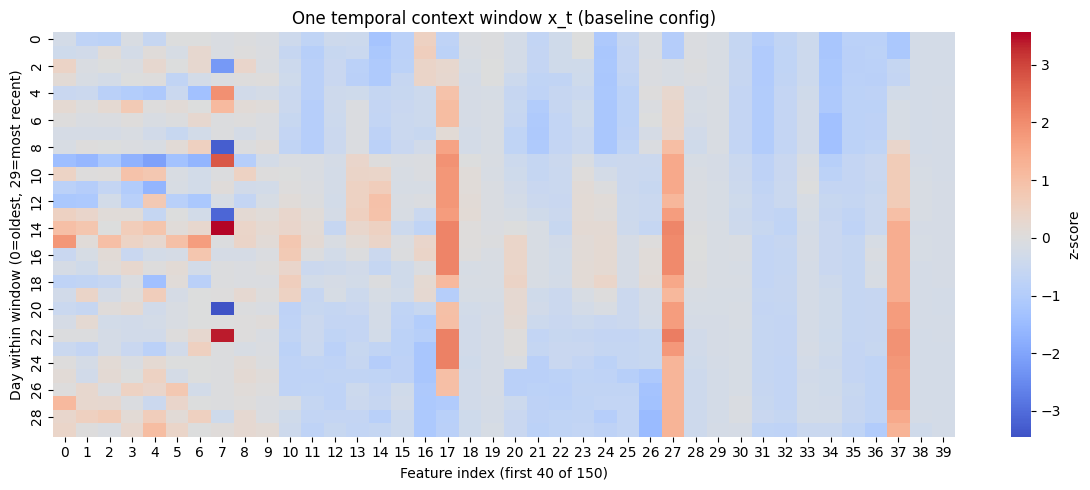

In [8]:
# Visualize a single window (x_t) as a heatmap: time (rows) x features (cols, first 40 shown for readability)
plt.figure(figsize=(12, 5))
sns.heatmap(windows[-1][:, :40], cmap='coolwarm', center=0, cbar_kws={'label': 'z-score'})
plt.xlabel('Feature index (first 40 of %d)' % windows.shape[2])
plt.ylabel('Day within window (0=oldest, %d=most recent)' % (windows.shape[1]-1))
plt.title('One temporal context window x_t (baseline config)')
plt.tight_layout()
plt.show()


## Experiment A — `window_size`

The window size controls how much history the LSTM/attention sees before producing `h_temp`. Too short → misses slow regime shifts. Too long → more noise, fewer usable windows (since your data is only ~5 years), slower training.

Try: **10, 20, 30 (baseline), 60, 90**


In [9]:
window_sizes = [10, 20, 30, 60, 90]
results = []

for ws in window_sizes:
    prep = Preprocessor(window_size=ws, normalize_method='zscore')
    feats = prep.engineer_features(prices, volumes)
    norm = prep.fit_normalize(feats)
    wins = prep.create_windows(norm.values)
    results.append({'window_size': ws, 'n_windows': wins.shape[0], 'n_features': wins.shape[2]})

df_ws = pd.DataFrame(results)
df_ws


,window_size,n_windows,n_features
0,10,807,150
1,20,797,150
2,30,787,150
3,60,757,150
4,90,727,150


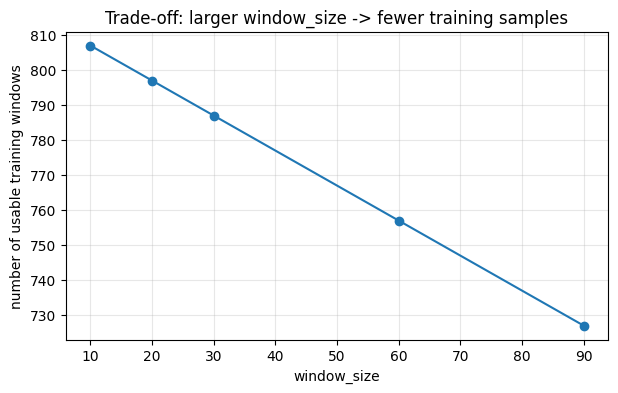


Observation prompt: with only ~836 raw days of banking-sector data, how much does going from 30 -> 90 actually cost you in usable samples? Is it worth it for the extra context?


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(7,4))
ax.plot(df_ws['window_size'], df_ws['n_windows'], marker='o')
ax.set_xlabel('window_size')
ax.set_ylabel('number of usable training windows')
ax.set_title('Trade-off: larger window_size -> fewer training samples')
ax.grid(alpha=0.3)
plt.show()

print("\nObservation prompt: with only ~%d raw days of banking-sector data, how much does going from 30 -> 90 "
      "actually cost you in usable samples? Is it worth it for the extra context?" % len(prices))


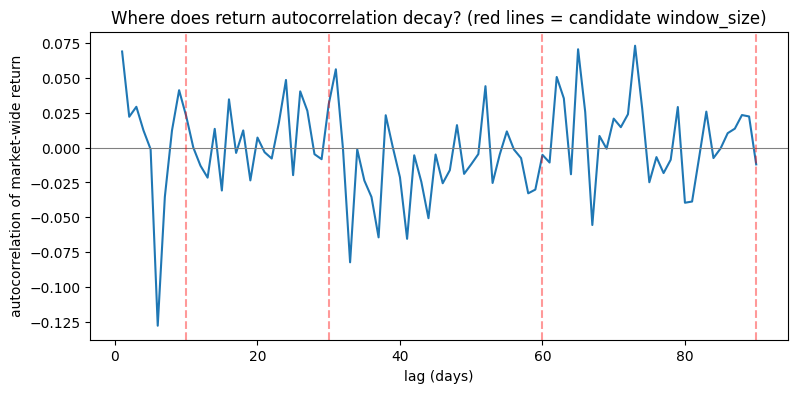

In [11]:
# Does the chosen window length actually capture regime persistence?
# Quick proxy: autocorrelation of average daily return across assets, at different lags.
avg_returns = np.log(prices / prices.shift(1)).mean(axis=1).dropna()

lags = range(1, 91)
acf_vals = [avg_returns.autocorr(lag=l) for l in lags]

plt.figure(figsize=(9,4))
plt.plot(list(lags), acf_vals)
plt.axhline(0, color='grey', lw=0.8)
for ws in [10, 30, 60, 90]:
    plt.axvline(ws, color='red', ls='--', alpha=0.4)
plt.xlabel('lag (days)')
plt.ylabel('autocorrelation of market-wide return')
plt.title('Where does return autocorrelation decay? (red lines = candidate window_size)')
plt.show()


**Your task:** based on the two plots above, pick a `window_size` and write 2-3 sentences on why (data-efficiency vs. how far back returns still show any dependence). There's no single "correct" answer — this is about learning to read the trade-off.

*(edit this cell with your answer)*

> Your answer:


## Experiment B — Feature groups

`engineer_features()` lets you toggle `use_returns`, `use_volatility`, `use_momentum`, `use_volume_features` (RSI, MACD, and Bollinger %B are always computed). Turning groups off changes both the *meaning* and the *size* of `x_t`.


In [12]:
feature_configs = {
    'all (baseline)':        dict(use_returns=True,  use_volatility=True,  use_momentum=True,  use_volume_features=True),
    'no_volume':             dict(use_returns=True,  use_volatility=True,  use_momentum=True,  use_volume_features=False),
    'returns_only_+core':    dict(use_returns=True,  use_volatility=False, use_momentum=False, use_volume_features=False),
    'no_returns':            dict(use_returns=False, use_volatility=True,  use_momentum=True,  use_volume_features=True),
}

rows = []
for name, kwargs in feature_configs.items():
    prep = Preprocessor(window_size=30, normalize_method='zscore')
    feats = prep.engineer_features(prices, volumes, **kwargs)
    rows.append({'config': name, 'n_features': feats.shape[1], 'n_timesteps': feats.shape[0]})

pd.DataFrame(rows)


,config,n_features,n_timesteps
0,all (baseline),150,816
1,no_volume,120,816
2,returns_only_+core,60,817
3,no_returns,140,816


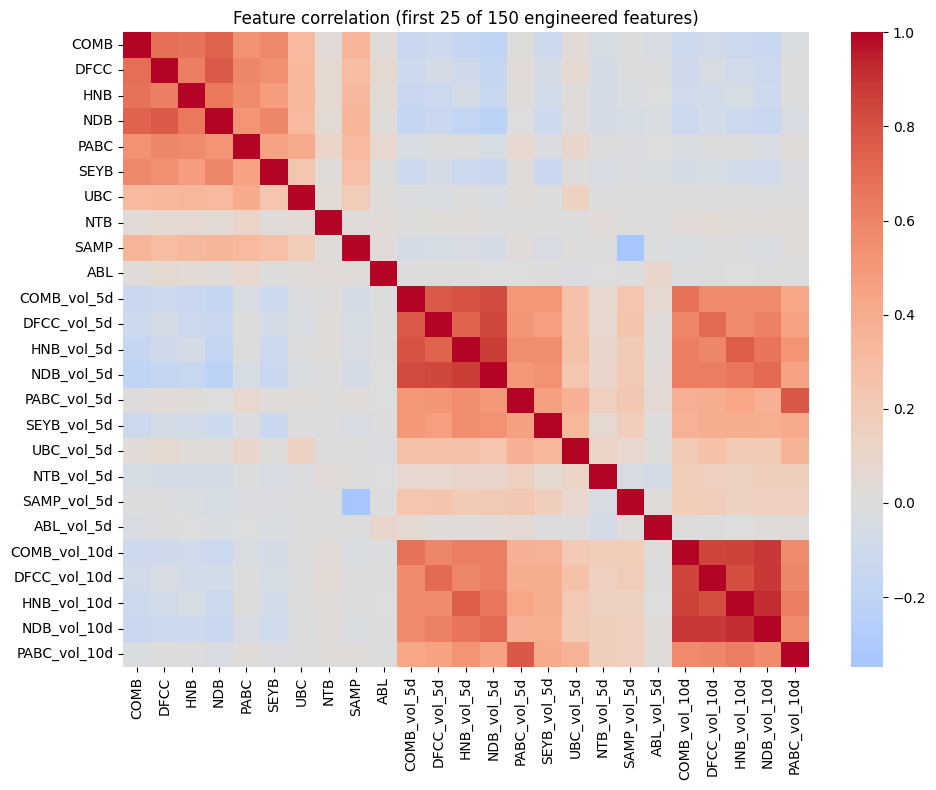

Look for near-duplicate feature pairs (dark red off-diagonal). Highly correlated inputs give the V-VSN (variable selection network) redundant signal to filter out -- worth knowing before Day 2.


In [13]:
# Correlation heatmap for the baseline feature set (first 25 features, to keep it readable)
prep = Preprocessor(window_size=30, normalize_method='zscore')
feats_baseline = prep.engineer_features(prices, volumes)

plt.figure(figsize=(10,8))
sns.heatmap(feats_baseline.iloc[:, :25].corr(), cmap='coolwarm', center=0)
plt.title('Feature correlation (first 25 of %d engineered features)' % feats_baseline.shape[1])
plt.tight_layout()
plt.show()

print("Look for near-duplicate feature pairs (dark red off-diagonal). Highly correlated inputs give the "
      "V-VSN (variable selection network) redundant signal to filter out -- worth knowing before Day 2.")


**Your task:** which feature group, if any, looks redundant with another (from the heatmap)? Would you drop it to make the V-VSN's job easier, or keep it as a "sanity check" signal?

> Your answer:


## Experiment C — Normalization method

`normalize_method` = `"zscore"` (baseline) | `"minmax"` | `"robust"`. This matters a lot for a market with occasional large single-day moves (fat tails) — robust scaling is less sensitive to outliers than z-score.


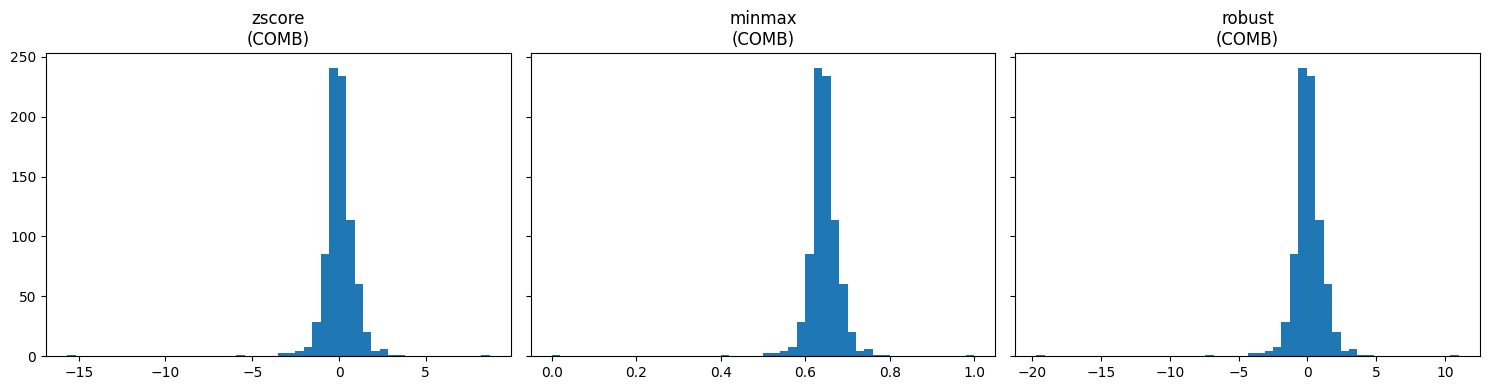

In [14]:
returns_baseline = preprocessor.compute_log_returns(prices)
example_col = returns_baseline.columns[0]

fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)
for ax, method in zip(axes, ['zscore', 'minmax', 'robust']):
    prep = Preprocessor(window_size=30, normalize_method=method)
    feats = prep.engineer_features(prices, volumes)
    norm = prep.fit_normalize(feats)
    col = [c for c in norm.columns if example_col in c][0]
    ax.hist(norm[col], bins=50)
    ax.set_title(f'{method}\n({col})')
plt.tight_layout()
plt.show()


**Your task:** does the distribution shape actually change much between methods for this asset? Given CSE banking stocks can have illiquid days with big price jumps, which method would you expect to be more stable to outliers, and does the plot support that?

> Your answer:


## Experiment D — `n_assets`

More assets = richer cross-sectional signal for the Macro Graph Prior (Day 4) but also a much larger action space for the Actor and more missing-data risk for illiquid banking stocks.


In [15]:
asset_counts = [5, 15, 30, 47]
rows = []
for n in asset_counts:
    p, v = loader.load_prices_and_volumes(n_assets=n)
    rows.append({'n_assets_requested': n, 'n_assets_returned': p.shape[1], 'n_dates': p.shape[0],
                 'date_start': p.index.min().date(), 'date_end': p.index.max().date()})
pd.DataFrame(rows)


,n_assets_requested,n_assets_returned,n_dates,date_start,date_end
0,5,5,836,2021-01-04,2025-12-31
1,15,10,836,2021-01-04,2025-12-31
2,30,10,836,2021-01-04,2025-12-31
3,47,10,836,2021-01-04,2025-12-31


**Your task:** does asking for more assets shrink the usable date range (because `load_prices_and_volumes` picks assets by lowest missingness, and adding more forces in less-complete series)? Trade this off against having more names for the portfolio to diversify across.

> Your answer:


## Wrap-up

Log your chosen Day 1 parameters below — you'll reuse these as the baseline going into Day 2 (Regime Encoder: VSN + LSTM).


In [16]:
day1_choices = {
    'window_size': None,          # fill in your choice, e.g. 30
    'use_returns': True,
    'use_volatility': True,
    'use_momentum': True,
    'use_volume_features': True,
    'normalize_method': None,     # 'zscore' | 'minmax' | 'robust'
    'n_assets': None,             # e.g. 47
}
import json
print(json.dumps(day1_choices, indent=2))
# (Optional) save to disk so Day 2 notebook can load it
with open('/content/day1_choices.json', 'w') as f:
    json.dump(day1_choices, f, indent=2)


{
  "window_size": null,
  "use_returns": true,
  "use_volatility": true,
  "use_momentum": true,
  "use_volume_features": true,
  "normalize_method": null,
  "n_assets": null
}


**Next up — Day 2:** the Differentiable Regime Encoder's V-VSN + LSTM block (`src/models/vsn_lstm.py`). You'll feed the `x_t` windows you just built into it and tune `vsn_hidden_dim`, `lstm_hidden_dim`, `lstm_num_layers`, and `lstm_dropout`, watching how `h_temp` and the learned variable-selection weights change.
